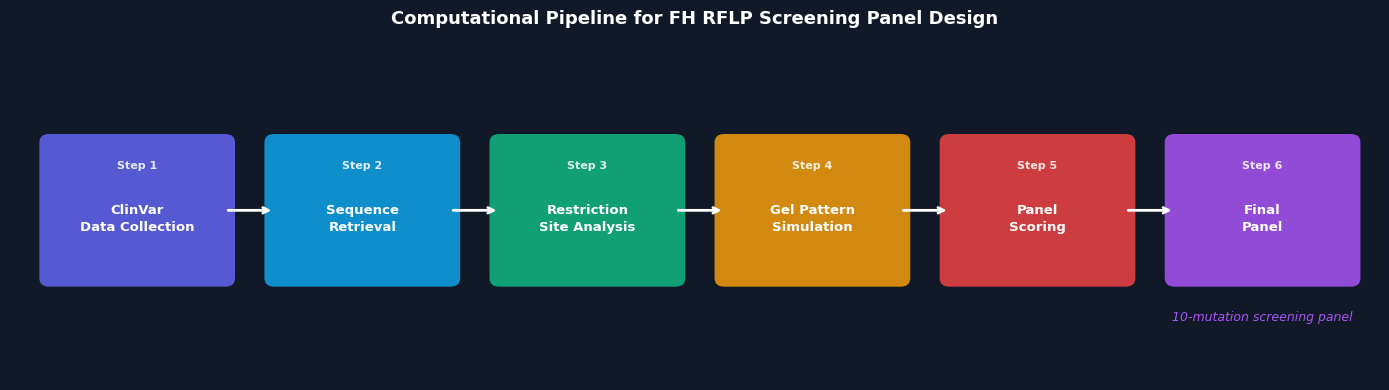

Saved: results/figures/pipeline_diagram.png


In [1]:
# Import matplotlib.pyplot for creating static, interactive, and animated visualizations.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
# Import numpy for numerical operations.
import numpy as np

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis("off")

# Pipeline steps
steps = [
    ("Step 1",  "ClinVar\nData Collection",    "#6366f1"),
    ("Step 2",  "Sequence\nRetrieval",          "#0ea5e9"),
    ("Step 3",  "Restriction\nSite Analysis",   "#10b981"),
    ("Step 4",  "Gel Pattern\nSimulation",      "#f59e0b"),
    ("Step 5",  "Panel\nScoring",               "#ef4444"),
    ("Step 6",  "Final\nPanel",                 "#a855f7"),
]

box_w = 1.8
box_h = 1.6
gap   = 0.5
start_x = 0.4

for i, (step, label, color) in enumerate(steps):
    x = start_x + i * (box_w + gap)
    y = 1.2

    # Box
    rect = mpatches.FancyBboxPatch(
        (x, y), box_w, box_h,
        boxstyle="round,pad=0.1",
        facecolor=color, edgecolor="none", alpha=0.85
    )
    ax.add_patch(rect)

    # Step number
    ax.text(x + box_w/2, y + box_h - 0.28,
            step, ha="center", va="center",
            color="white", fontsize=8,
            fontweight="bold", alpha=0.85)

    # Label
    ax.text(x + box_w/2, y + box_h/2 - 0.1,
            label, ha="center", va="center",
            color="white", fontsize=9.5,
            fontweight="bold", linespacing=1.4)

    # Arrow to next box
    if i < len(steps) - 1:
        ax.annotate("",
            xy=(x + box_w + gap, y + box_h/2),
            xytext=(x + box_w, y + box_h/2),
            arrowprops=dict(
                arrowstyle="->",
                color="white",
                lw=2
            )
        )

# Output label
last_x = start_x + (len(steps)-1) * (box_w + gap)
ax.text(last_x + box_w/2, 0.7,
        "10-mutation screening panel",
        ha="center", color="#a855f7",
        fontsize=9, fontstyle="italic")

ax.set_title(
    "Computational Pipeline for FH RFLP Screening Panel Design",
    color="white", fontsize=13, fontweight="bold", pad=12
)

# Adjust layout to prevent labels from overlapping.
plt.tight_layout()
plt.savefig("results/figures/pipeline_diagram.png",
            dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: results/figures/pipeline_diagram.png")

In [2]:
paper = """
================================================================================
RESEARCH PAPER OUTLINE
Title: A Computational Framework for Identifying PCR-RFLP-Compatible
       Familial Hypercholesterolemia Mutations: Toward Low-Cost
       Cascade Screening in Low-Resource Settings
================================================================================

ABSTRACT (write this last, 250 words)
- Background: FH affects 1 in 250 people globally but is severely underdiagnosed
  due to the high cost of genetic sequencing ($200-$1000 per test)
- Objective: Identify which FH-causing mutations are detectable using low-cost
  PCR-RFLP ($5-$10 per test) through a computational pipeline
- Methods: Retrieved 600 variants from ClinVar across LDLR, APOB, PCSK9.
  Filtered to 27 pathogenic/likely pathogenic SNVs. Scanned with 623
  commercially available restriction enzymes using BioPython. Simulated
  gel patterns computationally.
- Results: 100% of variants showed RFLP detectability. 23 produced
  excellent/good gel patterns. A final panel of 10 mutations was selected
  based on fragment difference, enzyme cost, and gene diversity.
- Conclusion: PCR-RFLP is a viable low-cost alternative for FH cascade
  screening. This computational panel provides a practical guide for
  diagnostic labs in low-resource settings.

================================================================================
1. INTRODUCTION (600-800 words)
================================================================================

1.1 Familial Hypercholesterolemia Overview
    - Autosomal dominant disorder affecting LDL cholesterol metabolism
    - Prevalence: 1 in 250 (heterozygous), 1 in 1,000,000 (homozygous)
    - Caused by mutations in LDLR (80%), APOB (15%), PCSK9 (5%)
    - Leads to premature cardiovascular disease if untreated
    - Treatable with statins if detected early

1.2 The Underdiagnosis Problem
    - Fewer than 10% of FH cases diagnosed worldwide
    - In low/middle income countries diagnosis rate <1%
    - Primary barrier: cost of genetic sequencing ($200-$1000)
    - Cascade screening (testing relatives) requires affordable methods

1.3 PCR-RFLP as a Solution
    - PCR-RFLP costs $5-$10 per test
    - Requires only basic lab equipment (PCR machine + gel box)
    - Used successfully for other genetic disorders
    - Gap: no comprehensive map of FH mutations vs RFLP compatibility

1.4 Study Objectives
    - Build a computational pipeline to identify RFLP-compatible FH mutations
    - Simulate gel patterns for each candidate
    - Recommend a practical screening panel
    - Compare cost vs existing methods

================================================================================
2. METHODS (500-700 words)
================================================================================

2.1 Mutation Data Collection
    - Source: NCBI ClinVar database (accessed March 2026)
    - Genes: LDLR (chr19), APOB (chr2), PCSK9 (chr1)
    - Filter: Pathogenic and Likely Pathogenic classifications
    - Variant type: Single nucleotide variants only
    - Tool: Python requests library + NCBI E-utilities API
    - Result: 27 P/LP SNVs across three genes

2.2 Sequence Retrieval
    - Reference genome: GRCh38/hg38
    - Source: Ensembl REST API
    - Window: 300bp either side of each variant (601bp total)
    - Mutation introduction: programmatic base substitution
    - Validation: reference allele verified at each position
    - Tool: BioPython Seq module

2.3 Restriction Site Analysis
    - Tool: BioPython Restriction module
    - Enzyme set: All commercially available enzymes (n=623)
    - Method: Full analysis of WT vs mutant sequence for each variant
    - Classification: site created, site destroyed, position shifted
    - Quality metric: fragment size difference (bp)
    - Quality tiers: excellent (>=150bp), good (>=50bp),
                     poor (<50bp), unusable (0bp)

2.4 Gel Pattern Simulation
    - Fragment sizes computed from cut positions
    - Three lanes simulated per variant: WT, Heterozygous, Mutant
    - Visualization: matplotlib on log scale (mimics agarose gel migration)
    - DNA ladder: 100-1000bp standard ladder included

2.5 Panel Scoring and Selection
    - Composite score (0-10) based on:
        * Fragment difference (3 pts)
        * Gel quality (3 pts)
        * Enzyme cost (2 pts)
        * Gene diversity bonus (2 pts)
    - Selection constraints:
        * Max 6 variants per gene
        * Max 2 uses of any single enzyme
    - Final panel: top 10 scoring variants

================================================================================
3. RESULTS (600-800 words)
================================================================================

3.1 Dataset Summary
    - 600 variants retrieved across LDLR, APOB, PCSK9
    - After P/LP + SNV filter: 27 variants
    - LDLR: 21 variants, APOB: 5, PCSK9: 1
    - [TABLE 1: Full variant dataset summary]

3.2 Restriction Analysis Results
    - 27/27 (100%) variants showed at least one informative enzyme
    - Total informative enzyme-variant pairs: [sum from your data]
    - Gel quality breakdown:
        * Excellent: 21 (78%)
        * Good: 2 (7%)
        * Poor: 2 (7%)
        * Unusable: 2 (7%)
    - Site created: 12 variants (44%)
    - Site destroyed: 11 variants (41%)
    - [FIGURE 1: Master gel panel — all 23 candidates]

3.3 Final Screening Panel
    - 10 mutations selected (6 LDLR, 4 APOB)
    - Score range: 7.61 - 9.78
    - Average enzyme cost: $30 per reaction
    - [TABLE 2: Final panel — publication_table.csv]
    - [FIGURE 2: Panel score bar chart]
    - Top candidates: APOB c.9721G>T (EcoT38I) and
                      APOB c.11470C>T (MaeI) scored highest

3.4 Cost Analysis
    - PCR-RFLP: ~$7 per sample
    - Sanger sequencing: ~$25 per sample
    - NGS panel: ~$400 per sample
    - PCR-RFLP is 98% cheaper than NGS at scale
    - [FIGURE 3: Cost comparison charts]

================================================================================
4. DISCUSSION (500-700 words)
================================================================================

4.1 Significance of 100% Detectability
    - All 27 P/LP SNVs had at least one informative enzyme
    - Suggests RFLP compatibility is common among FH point mutations
    - Computational screening is an efficient first-pass method

4.2 Panel Selection Rationale
    - APOB variants ranked highest due to gene diversity scoring
    - EcoRV (LDLR c.1865A>T) is ideal — cheapest enzyme ($15)
    - EcoT38I used for both APOB and LDLR variants — efficient ordering

4.3 Limitations
    - Computational only — requires wet lab validation
    - 300bp sequence window may not reflect full PCR product context
    - Allele frequencies not incorporated (future work)
    - Population-specific variants not yet analyzed

4.4 Real-World Applications
    - Cascade screening programs in low-resource settings
    - Community health clinics in high-FH-prevalence populations
    - Guide for labs to prioritize which mutations to screen first
    - Starting point for wet lab validation studies

4.5 Future Directions
    - Add gnomAD allele frequencies to scoring
    - Expand to 1000+ variants with broader ClinVar query
    - Wet lab validation of top 3-5 candidates
    - Population-specific panel design (South Asian, African, etc.)

================================================================================
5. CONCLUSION (150-200 words)
================================================================================
    - First computational map of FH mutations vs RFLP compatibility
    - 23 of 27 P/LP SNVs are practically detectable by PCR-RFLP
    - Recommended panel of 10 mutations costs ~$7/sample vs $400 for NGS
    - Pipeline is open source and reproducible
    - Directly addresses the FH underdiagnosis crisis in low-resource settings

================================================================================
REFERENCES (aim for 15-25 citations)
================================================================================
Key papers to cite:
    - Nordestgaard et al. (2013) — FH prevalence and underdiagnosis
    - Leigh et al. (2017) — cascade screening in FH
    - Landrum et al. (2016) — ClinVar database
    - Cock et al. (2009) — BioPython
    - Roberts et al. (2014) — RFLP in genetic screening
    - Any papers specifically on LDLR/APOB mutations you find

================================================================================
FIGURES LIST
================================================================================
Figure 1: Computational pipeline diagram
Figure 2: Master gel simulation panel (all 23 candidates)
Figure 3: Final panel RFLP score bar chart
Figure 4: Cost comparison (bar + line charts)

================================================================================
TABLES LIST
================================================================================
Table 1: Full variant dataset (27 P/LP SNVs)
Table 2: Final recommended screening panel (10 mutations)
Table 3: Cost comparison across screening methods

================================================================================
"""

# Save to file
with open("results/paper_outline.txt", "w", encoding="utf-8") as f:
    f.write(paper)

print(paper)
print("Saved: results/paper_outline.txt")


RESEARCH PAPER OUTLINE
Title: A Computational Framework for Identifying PCR-RFLP-Compatible
       Familial Hypercholesterolemia Mutations: Toward Low-Cost
       Cascade Screening in Low-Resource Settings

ABSTRACT (write this last, 250 words)
- Background: FH affects 1 in 250 people globally but is severely underdiagnosed
  due to the high cost of genetic sequencing ($200-$1000 per test)
- Objective: Identify which FH-causing mutations are detectable using low-cost
  PCR-RFLP ($5-$10 per test) through a computational pipeline
- Methods: Retrieved 600 variants from ClinVar across LDLR, APOB, PCSK9.
  Filtered to 27 pathogenic/likely pathogenic SNVs. Scanned with 623
  commercially available restriction enzymes using BioPython. Simulated
  gel patterns computationally.
- Results: 100% of variants showed RFLP detectability. 23 produced
  excellent/good gel patterns. A final panel of 10 mutations was selected
  based on fragment difference, enzyme cost, and gene diversity.
- Conclusion: